In [4]:
pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install opencv-python 

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install pillow matplotlib

In [7]:
pip install roboflow 

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import shutil
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
DATA_YAML_PATH = os.path.abspath("../Backend/data.yaml")

if os.path.exists(DATA_YAML_PATH):
    print(f"Found data.yaml at: {DATA_YAML_PATH}")
    with open(DATA_YAML_PATH, 'r') as f:
        print("\n--- YAML Content ---")
        print(f.read())
else:
    print(f"Error: Could not find data.yaml at {DATA_YAML_PATH}")

Found data.yaml at: C:\Users\Samruddhi pai\Desktop\Git_demo\MiMediCare\Backend\data.yaml

--- YAML Content ---
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['IBUPROFEN AND PARACETAMOL TABLETS', 'Medicine-Name']

roboflow:
  workspace: medicine-label
  project: medicine-crimp
  version: 1
  license: Public Domain
  url: https://universe.roboflow.com/medicine-label/medicine-crimp/dataset/1


In [3]:
# Load the pretrained weights (YOLOv8 Nano is best for local training)
model = YOLO('yolov8n.pt') 

print("Base model 'yolov8n' loaded successfully.")

Base model 'yolov8n' loaded successfully.


In [4]:
# Start training
# Reduce epochs to 20 or 30 if your laptop is getting too hot
results = model.train(
    data=DATA_YAML_PATH,
    epochs=20,       
    imgsz=640,       
    batch=16,        
    name='medicine_detector',
    device='cpu'     # Change to 0 if you have an NVIDIA GPU
)

Ultralytics 8.4.46  Python-3.12.12 torch-2.11.0+cpu CPU (AMD Ryzen 5 5500U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Samruddhi pai\Desktop\Git_demo\MiMediCare\Backend\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=medicine_detector-3, nbs=64, nms=False, opset=None

<Figure size 640x480 with 0 Axes>

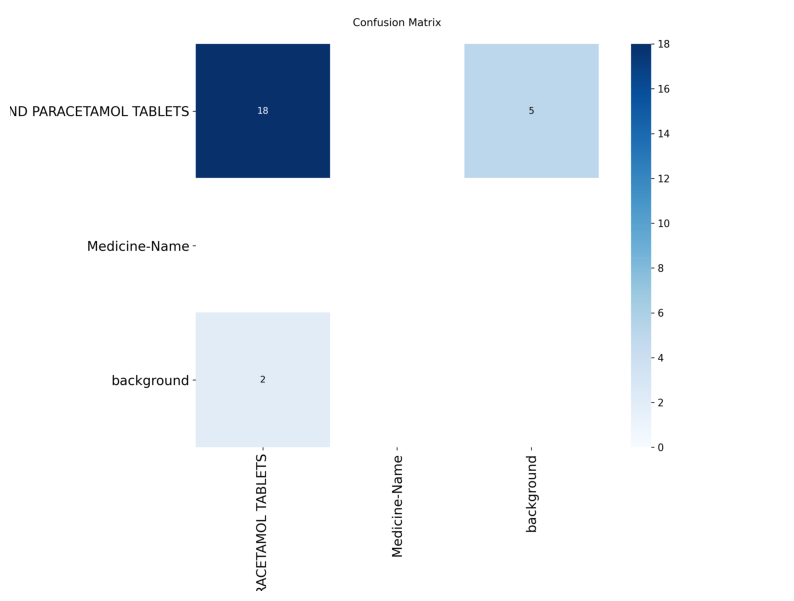

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
import os

# Using the path confirmed from your previous screenshot
matrix_path = 'runs/detect/medicine_detector-3/confusion_matrix.png'

if os.path.exists(matrix_path):
    # Clear any previous stuck plots
    plt.clf() 
    
    img = Image.open(matrix_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show() # This forces the render
else:
    print(f"File not found at: {os.path.abspath(matrix_path)}")


image 1/1 C:\Users\Samruddhi pai\Desktop\Git_demo\MiMediCare\Backend\..\Backend\valid\images\IMG_5689_JPG.rf.059a2439d65f7abcc1ee57222444fc97.jpg: 640x640 1 IBUPROFEN AND PARACETAMOL TABLETS, 153.9ms
Speed: 9.2ms preprocess, 153.9ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


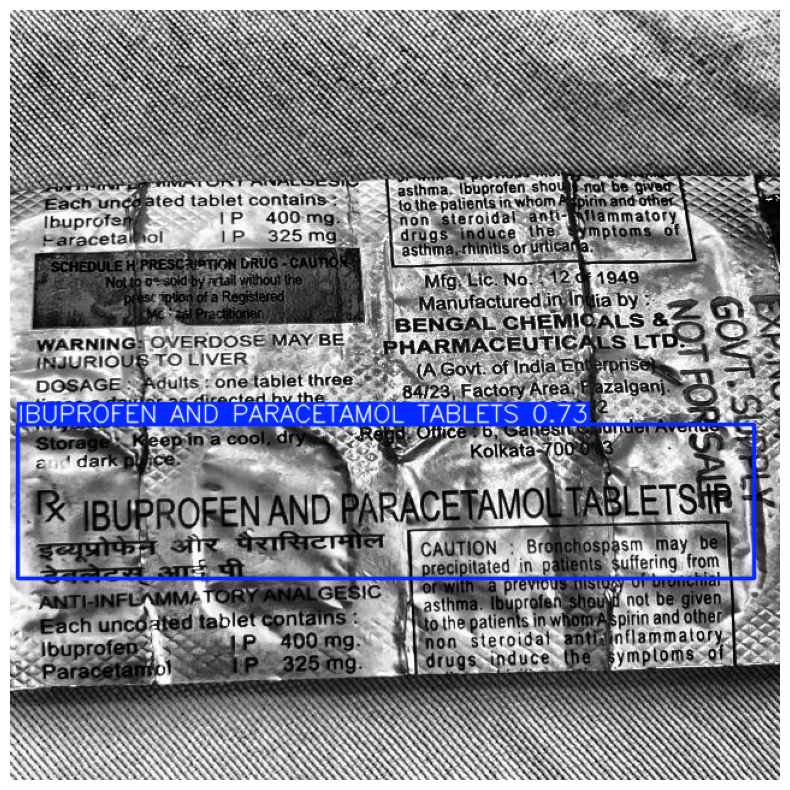

In [13]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load your best trained model
model = YOLO('runs/detect/medicine_detector-3/weights/best.pt')

# 2. Predict on a sample image (point this to an image in your 'val' folder)
# Replace 'test_sample.jpg' with an actual filename from your dataset
test_img = '../Backend/valid/images/IMG_5689_JPG.rf.059a2439d65f7abcc1ee57222444fc97.jpg' 

results = model.predict(source=test_img, conf=0.5)

# 3. Show the result with the Bounding Box
for r in results:
    im_array = r.plot()  # Plot the boxes and labels
    im = Image.fromarray(im_array[..., ::-1])  # Convert BGR to RGB
    plt.figure(figsize=(10, 10))
    plt.imshow(im)
    plt.axis('off')
    plt.show()

In [17]:
import shutil
os.makedirs('../models', exist_ok=True)
shutil.copy('runs/detect/medicine_detector-3/weights/best.pt', '../Backend/models/pill_model.pt')
print("Pill recognition model is now in the central models folder!")

Pill recognition model is now in the central models folder!
